In [ ]:
pip install gensim

In [ ]:
pip install nltk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from gensim.models import Word2Vec
import gensim
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
import warnings
from nltk.corpus import stopwords
from sklearn.decomposition import PCA
nltk.download('punkt_tab')

warnings.filterwarnings(action='ignore')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
data = pd.read_csv('chordonomicon.csv')
chords = data['chords']
chords

,chords
0,<intro_1> C <verse_1> F C E7 Amin C F C G7 C F...
1,<intro_1> E D A/Cs E D A/Cs <verse_1> E D A/Cs...
2,<intro_1> D Dmaj7 D Dmaj7 <verse_1> Emin A D G...
3,<intro_1> C <verse_1> G C G C <chorus_1> F Dmi...
4,<intro_1> C G C G <verse_1> C G C G C Bmin Emi...
...,...
667853,Bbadd13 Eb Cmin F Bbadd13 Eb7 Cmin F7 Cmin F7 ...
667854,Bbmin7 Abadd13 Ab7 Ab7sus4 Abdim7 Adim Amin7 B...
667855,Bmaj7 Bmaj7sus2 Amaj7 Amaj7sus2 Bmaj7 Bmaj7sus...
667856,Eb9 E9 F9 Eb9 E9 F9 Fmaj9 Eb7sus4 Fmaj9 Eb7sus...


In [ ]:
# Find all instances of words enclosed by "<>"
pattern = r'<([^>]+)>'
tags = data['chords'].str.findall(pattern).explode().unique().tolist()
print("Words enclosed by '<>':")
print(tags)

Words enclosed by '<>':
['intro_1', 'verse_1', 'verse_2', 'chorus_1', 'solo_1', 'chorus_2', 'bridge_1', 'chorus_3', 'bridge_2', 'outro_1', 'outro_2', 'verse_3', 'chorus_4', 'interlude_1', 'interlude_2', 'interlude_3', 'interlude_4', nan, 'verse_4', 'verse_5', 'instrumental_1', 'instrumental_2', 'instrumental_3', 'instrumental_4', 'chorus_5', 'verse_6', 'verse_7', 'verse_8', 'verse_9', 'chorus_6', 'solo_2', 'solo_3', 'bridge_3', 'bridge_4', 'intro_2', 'solo_4', 'interlude_5', 'interlude_6', 'interlude_7', 'interlude_8', 'intro_3', 'instrumental_5', 'intro_4', 'chorus_7', 'chorus_8', 'chorus_9', 'chorus_10', 'chorus_11', 'verse_10', 'chorus_12', 'verse_11', 'verse_12', 'verse_13', 'verse_14', 'verse_15', 'verse_16', 'verse_17', 'verse_18', 'verse_19', 'verse_20', 'chorus_13', 'verse_21', 'chorus_14', 'verse_22', 'chorus_15', 'verse_23', 'verse_24', 'chorus_16', 'verse_25', 'verse_26', 'chorus_17', 'verse_27', 'verse_28', 'chorus_18', 'verse_29', 'verse_30', 'chorus_19', 'verse_31', 'vers

In [ ]:
# Remove all instances of words enclosed by "<>"
data['chords_cleaned'] = data['chords'].str.replace(pattern, '', regex=True)
data[['chords', 'chords_cleaned']].head()

,chords,chords_cleaned
0,<intro_1> C <verse_1> F C E7 Amin C F C G7 C F...,C F C E7 Amin C F C G7 C F C E7 Amin C F G7 ...
1,<intro_1> E D A/Cs E D A/Cs <verse_1> E D A/Cs...,E D A/Cs E D A/Cs E D A/Cs E D A/Cs E D A/Cs...
2,<intro_1> D Dmaj7 D Dmaj7 <verse_1> Emin A D G...,D Dmaj7 D Dmaj7 Emin A D G Emin A D G Emin A...
3,<intro_1> C <verse_1> G C G C <chorus_1> F Dmi...,C G C G C F Dmin G Dmin G C G C F Dmin G ...
4,<intro_1> C G C G <verse_1> C G C G C Bmin Emi...,C G C G C G C G C Bmin Emin Amin D G C D G ...


In [ ]:
chord_progs = data['chords_cleaned'].values
new_vec = [nltk.word_tokenize(sent) for sent in chord_progs]
new_vec[0]

['C',
 'F',
 'C',
 'E7',
 'Amin',
 'C',
 'F',
 'C',
 'G7',
 'C',
 'F',
 'C',
 'E7',
 'Amin',
 'C',
 'F',
 'G7',
 'C',
 'F',
 'C',
 'E7',
 'Amin',
 'C',
 'F',
 'C',
 'G7',
 'C',
 'F',
 'C',
 'E7',
 'Amin',
 'C',
 'F',
 'G7',
 'C',
 'F',
 'C',
 'F',
 'C',
 'G',
 'C',
 'F',
 'C',
 'E7',
 'Amin',
 'C',
 'F',
 'G7',
 'C',
 'D',
 'G',
 'D',
 'G',
 'D',
 'A',
 'D',
 'G',
 'D',
 'Fs7',
 'Bmin',
 'D',
 'G',
 'A7',
 'D',
 'G',
 'A7',
 'D']

In [ ]:
model = Word2Vec(sentences=new_vec, vector_size=100, window=5, min_count=1, workers=4, sg=1)
model.save("word2vec_fine_tuned.model")

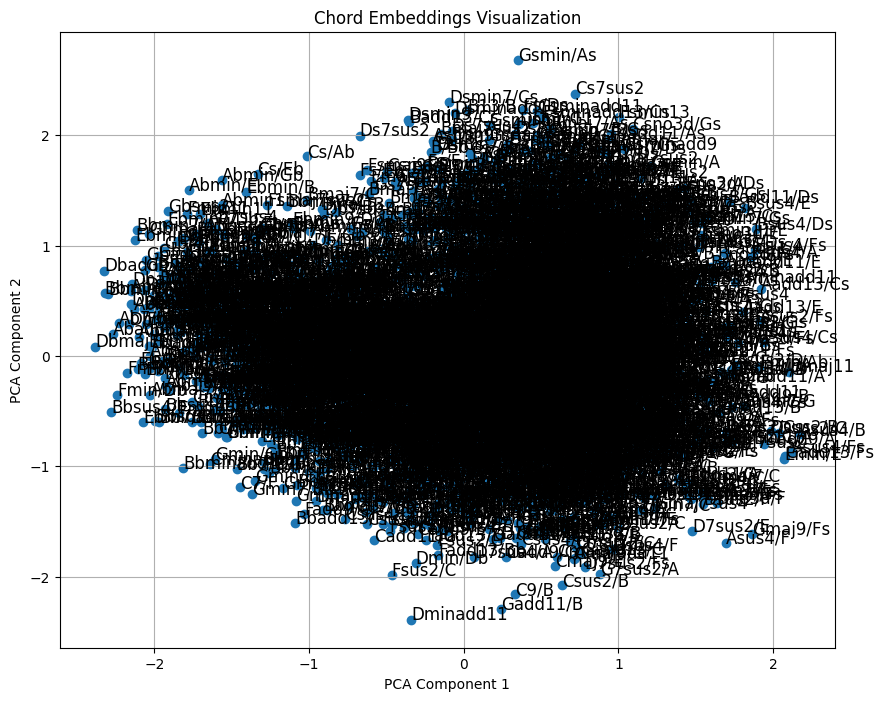

In [ ]:
# Reduce dimensionality of chord vectors for visualization
word_vectors = model.wv[model.wv.index_to_key]  # Get the chord vectors
pca = PCA(n_components=2)  # Initialize PCA
result = pca.fit_transform(word_vectors)  # Fit and transform the chord vectors

# Plot the chords in a 2D space
plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

# Annotate chords in the plot
words = list(model.wv.index_to_key)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Chord Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

In [ ]:
try:
    chord = 'Gmaj7'
    similar_chords = model.wv.most_similar(chord, topn=10)
    print(f"Most similar chords to {chord} :", similar_chords)
except KeyError as e:
    print(f"KeyError: {e}")

try:
    chord = 'D'
    similar_chords= model.wv.most_similar(chord, topn=1000)
    print(f"Most similar chords to {chord} :", similar_chords)
except KeyError as e:
    print(f"KeyError: {e}")

Most similar chords to Gmaj7 : [('Bminadd9/A', 0.6749069690704346), ('Fs7b9/Cs', 0.644324541091919), ('Gs7/D', 0.6314162015914917), ('B7b9/D', 0.6193058490753174), ('Eminadd11/F', 0.6192836165428162), ('Gmaj7/Gb', 0.617401659488678), ('A7sus2/B', 0.6163366436958313), ('Daug/C', 0.6148717999458313), ('Aadd13/G', 0.613400936126709), ('Dadd9/Gb', 0.607155978679657)]
Most similar chords to D : [('Bmin', 0.6935442090034485), ('G', 0.6341466307640076), ('Csmaj7/Cs', 0.5893027782440186), ('Csadd11/E', 0.5826284885406494), ('Esus4/Eb', 0.5779241323471069), ('A', 0.572037398815155), ('G7/Gs', 0.5708323121070862), ('D/Fs', 0.5705207586288452), ('Gbno3d/B', 0.5617108345031738), ('C11/D', 0.5602474808692932), ('Emin', 0.534889280796051), ('Dadd11/D', 0.5342186093330383), ('C9/Eb', 0.5336606502532959), ('Dsus4', 0.5328107476234436), ('G/Fs', 0.52897709608078), ('Bbdim13b9', 0.5286279916763306), ('Aadd11/Ab', 0.5207290649414062), ('Fsmin', 0.5104284286499023), ('Bbdim/G', 0.5062262415885925), ('Fssu